# PySlice Performance Benchmark

This notebook tests the performance of PySlice loss landscape analysis on tiny neural networks, comparing CPU vs GPU performance in Google Colab.

We'll measure how fast PySlice can perform 10,000 random direction evaluations on neural networks with 2-10 parameters.

In [28]:
# !git clone https://github.com/joeseegtatz/loss-slicer.git
# !cd loss-slicer/ && pip install -r requirements.txt
# !cd loss-slicer/ && pip install .

In [29]:
# Import required libraries
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from examples.example_models import generate_sample_data
from pysclice.core.model_wrapper import ModelWrapper

# Check available devices
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

PyTorch version: 2.8.0
CUDA available: False


In [30]:
def create_mlp(layer_sizes):
    """Create MLP with specified layer sizes."""
    layers = []
    for i in range(len(layer_sizes) - 1):
        layers.append(torch.nn.Linear(layer_sizes[i], layer_sizes[i+1]))
        if i < len(layer_sizes) - 2:
            layers.append(torch.nn.ReLU())
    return torch.nn.Sequential(*layers)

# Test the function by creating sample models and showing parameter counts
test_configs = [
    ("4 params", [3, 1]),
    ("8 params", [3, 2, 1]),
    ("12 params", [3, 3, 1]),
]

print("Testing model configurations:")
for name, config in test_configs:
    test_model = create_mlp(config)
    test_params = sum(p.numel() for p in test_model.parameters())
    print(f"  {name}: {test_params} parameters (config: {config})")

print("Model creation function works correctly!")

Testing model configurations:
  4 params: 4 parameters (config: [3, 1])
  8 params: 11 parameters (config: [3, 2, 1])
  12 params: 16 parameters (config: [3, 3, 1])
Model creation function works correctly!


In [31]:
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [32]:
# Test configurations
TARGET_EVALUATIONS = 10000
devices = ['cpu', 'cuda', 'mps'] if torch.cuda.is_available() else ['cpu', 'mps']

# Very small model architectures (all with ≤12 parameters)
# Note: Input size must be 3 to match our training data
model_configs = [
    ("4 params", [3, 1]),
    ("8 params", [3, 2, 1]),
    ("12 params", [3, 3, 1]),
    ("20 params", [3, 4, 1]),
    ("32 params", [3, 5, 2, 1]),
    ("72 params", [3, 8, 4, 2, 1]),
    ("156 params", [3, 10, 6, 3, 1]),
    ("372 params", [3, 20, 10, 5, 1]),
]

print(f"Target evaluations: {TARGET_EVALUATIONS:,}")
print(f"Available devices: {devices}")
print(f"Model configurations: {len(model_configs)} different sizes")

# Print actual parameter counts
print("\nActual parameter counts:")
for name, config in model_configs:
    test_model = create_mlp(config) if 'create_mlp' in locals() else None
    if test_model:
        actual_params = sum(p.numel() for p in test_model.parameters())
        print(f"  {name}: {actual_params} parameters (config: {config})")
    else:
        # Calculate manually
        total_params = 0
        for i in range(len(config) - 1):
            total_params += config[i] * config[i+1] + config[i+1]  # weights + bias
        print(f"  {name}: {total_params} parameters (config: {config})")

Target evaluations: 10,000
Available devices: ['cpu', 'mps']
Model configurations: 8 different sizes

Actual parameter counts:
  4 params: 4 parameters (config: [3, 1])
  8 params: 11 parameters (config: [3, 2, 1])
  12 params: 16 parameters (config: [3, 3, 1])
  20 params: 21 parameters (config: [3, 4, 1])
  32 params: 35 parameters (config: [3, 5, 2, 1])
  72 params: 81 parameters (config: [3, 8, 4, 2, 1])
  156 params: 131 parameters (config: [3, 10, 6, 3, 1])
  372 params: 351 parameters (config: [3, 20, 10, 5, 1])


In [33]:
# Generate sample data with smaller input size for tiny models
train_data = generate_sample_data(input_size=3, num_samples=100)

print(f"Generated training data:")
print(f"  Input shape: {train_data[0].shape}")
print(f"  Target shape: {train_data[1].shape}")
print(f"  Input sample range: [{train_data[0].min():.3f}, {train_data[0].max():.3f}]")
print(f"  Target sample range: [{train_data[1].min():.3f}, {train_data[1].max():.3f}]")

Generated training data:
  Input shape: torch.Size([100, 3])
  Target shape: torch.Size([100, 1])
  Input sample range: [-2.585, 2.218]
  Target sample range: [-4.648, 4.392]


## Running the Performance Benchmark

Now we'll run the main benchmark, testing each model configuration on each available device. This will take a few minutes to complete.

In [34]:
# Run benchmark
results = []

print(f"Available devices: {devices}")
print(f"CUDA available: {torch.cuda.is_available()}")
print("\nStarting benchmark...")

for device in devices:
    print(f"\nTesting {device.upper()}:")
    
    for model_name, config in model_configs:
        model = create_mlp(config)
        param_count = sum(p.numel() for p in model.parameters())
        
        wrapper = ModelWrapper(model, torch.nn.MSELoss(), train_data, device=device)
        base_params = wrapper.get_parameters()
        
        # Perform 10,000 random direction evaluations
        start_time = time.time()
        
        for i in range(TARGET_EVALUATIONS):
            # Generate random direction and modify parameters slightly
            random_direction = np.random.normal(0, 0.1, size=base_params.shape)
            modified_params = base_params + random_direction
            
            # Compute loss with modified parameters
            loss = wrapper.compute_loss(modified_params, use_test_data=False)
        
        elapsed_time = time.time() - start_time
        
        results.append({
            'device': device,
            'model': model_name,
            'params': param_count,
            'time': elapsed_time,
            'evaluations': TARGET_EVALUATIONS
        })
        
        evals_per_sec = TARGET_EVALUATIONS / elapsed_time
        print(f"  {model_name:10s}: {param_count:2d} params, {elapsed_time:6.2f}s ({evals_per_sec:6.1f} evals/sec)")

print("\nBenchmark completed!")

Available devices: ['cpu', 'mps']
CUDA available: False

Starting benchmark...

Testing CPU:
  4 params  :  4 params,   0.84s (11893.5 evals/sec)
  8 params  : 11 params,   1.32s (7577.6 evals/sec)
  12 params : 16 params,   1.24s (8043.5 evals/sec)
  20 params : 21 params,   1.23s (8123.6 evals/sec)
  32 params : 35 params,   1.61s (6225.3 evals/sec)
  72 params : 81 params,   1.99s (5036.6 evals/sec)
  156 params: 131 params,   2.12s (4708.4 evals/sec)
  372 params: 351 params,   2.14s (4680.5 evals/sec)

Testing MPS:
  4 params  :  4 params,  15.07s ( 663.4 evals/sec)
  8 params  : 11 params,  17.50s ( 571.5 evals/sec)
  12 params : 16 params,  16.91s ( 591.3 evals/sec)
  20 params : 21 params,  18.35s ( 544.9 evals/sec)
  32 params : 35 params,  19.91s ( 502.4 evals/sec)
  72 params : 81 params,  21.08s ( 474.3 evals/sec)
  156 params: 131 params,  22.53s ( 443.9 evals/sec)
  372 params: 351 params,  21.76s ( 459.6 evals/sec)

Benchmark completed!


## Visualizing Results

Let's create visualizations to understand the performance characteristics of PySlice on different devices and model sizes.

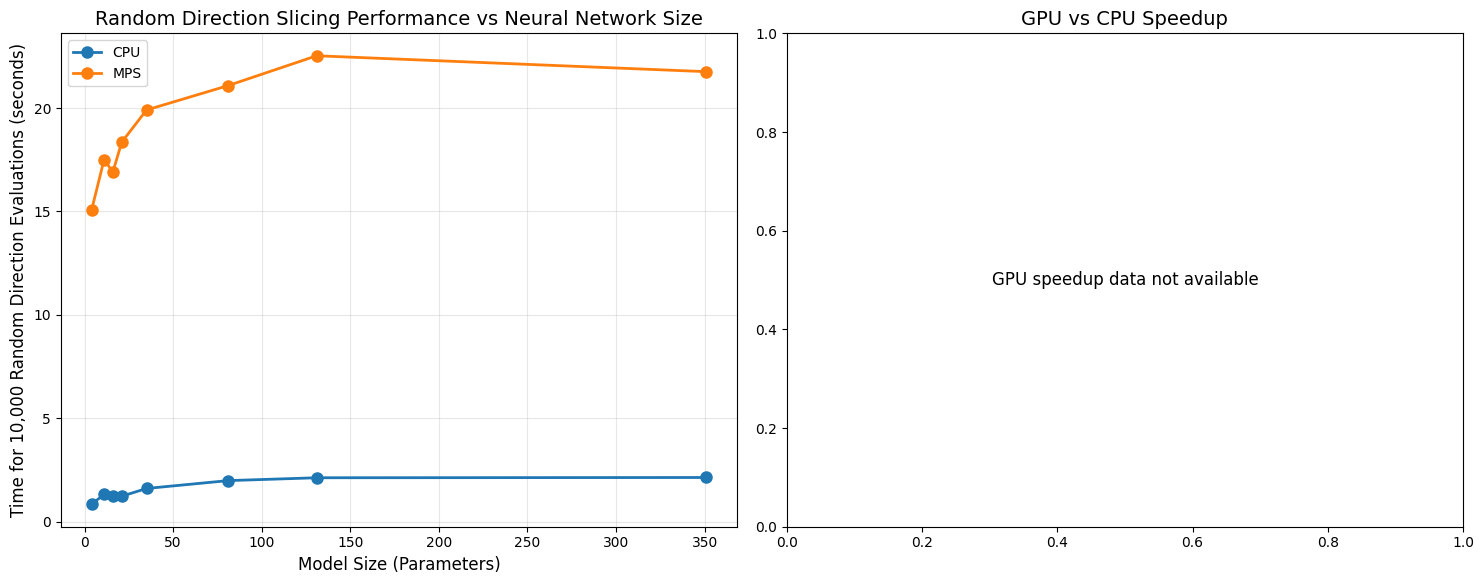

In [35]:
# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Time vs Model Size
for device in devices:
    device_data = [r for r in results if r['device'] == device]
    x = [r['params'] for r in device_data]
    y = [r['time'] for r in device_data]
    ax1.plot(x, y, 'o-', label=device.upper(), markersize=8, linewidth=2)

ax1.set_xlabel('Model Size (Parameters)')
ax1.set_ylabel('Time for 10,000 Random Direction Evaluations (seconds)')
ax1.set_title('Random Direction Slicing Performance vs Neural Network Size')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Speedup comparison (only if both CPU and GPU data available)
if len(devices) > 1:
    cpu_data = [r for r in results if r['device'] == 'cpu']
    gpu_data = [r for r in results if r['device'] == 'cuda']
    
    if len(cpu_data) == len(gpu_data):
        speedup = [cpu_data[i]['time'] / gpu_data[i]['time'] for i in range(len(cpu_data))]
        x = [r['params'] for r in cpu_data]
        ax2.plot(x, speedup, 'o-', color='green', markersize=8, linewidth=2)
        ax2.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No speedup')
        ax2.set_xlabel('Model Size (Parameters)')
        ax2.set_ylabel('Speedup (CPU time / GPU time)')
        ax2.set_title('GPU vs CPU Speedup')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Add text annotations for speedup values
        for i, (param, speed) in enumerate(zip(x, speedup)):
            ax2.annotate(f'{speed:.1f}x', (param, speed), 
                        textcoords="offset points", xytext=(0,10), ha='center')
    else:
        ax2.text(0.5, 0.5, 'GPU speedup data not available', 
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('GPU vs CPU Speedup')
else:
    ax2.text(0.5, 0.5, 'Only CPU data available', 
            ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('GPU vs CPU Speedup')

plt.tight_layout()
plt.show()

## Performance Summary

Here's a detailed breakdown of the performance results:

In [36]:
# Print detailed summary
print("=" * 60)
print("PERFORMANCE SUMMARY")
print("=" * 60)

for device in devices:
    device_data = [r for r in results if r['device'] == device]
    print(f"\n{device.upper()} Results:")
    print("-" * 40)
    for r in device_data:
        evals_per_sec = r['evaluations'] / r['time']
        print(f"  {r['model']:10s}: {evals_per_sec:6.1f} evals/sec ({r['time']:5.2f}s total)")

# Calculate and display speedup summary
if len(devices) > 1:
    print("\nSPEEDUP ANALYSIS:")
    print("-" * 40)
    cpu_data = [r for r in results if r['device'] == 'cpu']
    gpu_data = [r for r in results if r['device'] == 'cuda']
    
    if len(cpu_data) == len(gpu_data):
        total_speedup = [cpu_data[i]['time'] / gpu_data[i]['time'] for i in range(len(cpu_data))]
        avg_speedup = np.mean(total_speedup)
        max_speedup = np.max(total_speedup)
        min_speedup = np.min(total_speedup)
        
        print(f"  Average GPU speedup: {avg_speedup:.1f}x")
        print(f"  Maximum GPU speedup: {max_speedup:.1f}x")
        print(f"  Minimum GPU speedup: {min_speedup:.1f}x")
        
        if avg_speedup > 1:
            print(f"  → GPU is {avg_speedup:.1f}x faster on average")
        else:
            print(f"  → CPU is {1/avg_speedup:.1f}x faster on average")

print(f"\nTest completed with {TARGET_EVALUATIONS:,} evaluations per model configuration.")

PERFORMANCE SUMMARY

CPU Results:
----------------------------------------
  4 params  : 11893.5 evals/sec ( 0.84s total)
  8 params  : 7577.6 evals/sec ( 1.32s total)
  12 params : 8043.5 evals/sec ( 1.24s total)
  20 params : 8123.6 evals/sec ( 1.23s total)
  32 params : 6225.3 evals/sec ( 1.61s total)
  72 params : 5036.6 evals/sec ( 1.99s total)
  156 params: 4708.4 evals/sec ( 2.12s total)
  372 params: 4680.5 evals/sec ( 2.14s total)

MPS Results:
----------------------------------------
  4 params  :  663.4 evals/sec (15.07s total)
  8 params  :  571.5 evals/sec (17.50s total)
  12 params :  591.3 evals/sec (16.91s total)
  20 params :  544.9 evals/sec (18.35s total)
  32 params :  502.4 evals/sec (19.91s total)
  72 params :  474.3 evals/sec (21.08s total)
  156 params:  443.9 evals/sec (22.53s total)
  372 params:  459.6 evals/sec (21.76s total)

SPEEDUP ANALYSIS:
----------------------------------------

Test completed with 10,000 evaluations per model configuration.


## Key Insights

This benchmark reveals important insights about PySlice performance:

1. **Model Size Impact**: How computational time scales with the number of parameters
2. **Device Performance**: Whether GPU acceleration provides benefits for small models
3. **Overhead Analysis**: The computational cost of parameter manipulation vs. forward passes
4. **Scalability**: How performance characteristics change as model complexity increases

For loss landscape analysis with PySlice, these results help determine:
- Optimal device selection for different model sizes
- Expected computation times for slicing operations
- Trade-offs between analysis resolution and computational cost